imports

In [1]:
import importlib
import numpy as np
import pandas as pd
import os

import load_data
import assign_labels
import build_features
import train
import plots
import extract_ontology
import build_topology_graph
import build_ontology
import symbolic_features

importlib.reload(load_data)
importlib.reload(assign_labels)
importlib.reload(build_features)
importlib.reload(train)
importlib.reload(plots)
importlib.reload(extract_ontology)
importlib.reload(build_topology_graph)
importlib.reload(build_ontology)
importlib.reload(symbolic_features)

from load_data import load_alerts_from_json
from assign_labels import add_labels_to_df
from build_features import build_dyn_features, build_static_features
from symbolic_features import build_symbolic_features
from train import run_experiment
from plots import (
    plot_roc,
    plot_alert_reduction,
    plot_feature_importance,
    plot_confidence_distribution,
    plot_top_error_categories,
    plot_all,
    plot_symbolic_coefficients,
    plot_symbolic_performance_delta,
    plot_symbolic_score_shift
)
from extract_ontology import topology_edges, host_sets
from build_topology_graph import plot_scenario_topologies
from build_ontology import build_all_scenarios


### Load data
##### Wazuh + Aminer Alerts (AIT-ADS, .json format) to .csv

In [15]:
output_file = "combined_ait.csv"
dir_path = "../data/ait_ads"

df = load_alerts_from_json(output_file, dir_path)

Opening file ../data/ait_ads/harrison_aminer.json...
Opening file ../data/ait_ads/wardbeck_wazuh.json...
Opening file ../data/ait_ads/wheeler_wazuh.json...
Opening file ../data/ait_ads/shaw_wazuh.json...
Opening file ../data/ait_ads/wilson_aminer.json...
Opening file ../data/ait_ads/fox_aminer.json...
Opening file ../data/ait_ads/santos_wazuh.json...
Opening file ../data/ait_ads/fox_wazuh.json...
Opening file ../data/ait_ads/shaw_aminer.json...
Opening file ../data/ait_ads/wheeler_aminer.json...
Opening file ../data/ait_ads/russellmitchell_aminer.json...
Opening file ../data/ait_ads/harrison_wazuh.json...
Opening file ../data/ait_ads/wilson_wazuh.json...
Opening file ../data/ait_ads/santos_aminer.json...
Opening file ../data/ait_ads/russellmitchell_wazuh.json...
Opening file ../data/ait_ads/wardbeck_aminer.json...
Writing data to combined_ait.csv...

...
Done.


##### Load .csv to notebook

In [29]:
df = pd.read_csv("../data/ait_ads/combined_ait.csv")
df.head()
print(df["timestamp"].min(), df["timestamp"].max())
df["timestamp"].map(type).value_counts()

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_3174/912057347.py:1: DtypeWarning: Columns (7,10,12,13,14,17,24,31,32,36,37,38,39,40,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ait_ads/combined_ait.csv")


2022-01-14 00:00:01.750000+00:00 2022-02-08 23:59:46.130000114+00:00


timestamp
<class 'str'>    2655821
Name: count, dtype: int64

#### Sanity checks

In [19]:
df.columns

Index(['timestamp', 'category', 'entity', 'raw_log', 'scenario', 'source',
       'host_ip', 'host', 'rule_id', 'rule_desc', 'groups', 'groups_raw',
       'groups_str', 'srcip', 'dstip', 'srcport', 'dstport', 'proto',
       'is_auth_event', 'is_cred_event', 'is_web_event', 'is_cron',
       'is_success', 'is_uid0', 'aminer_component_type',
       'aminer_training_mode', 'aminer_new_event', 'wazuh_level',
       'wazuh_antivirus', 'wazuh_update', 'is_ids_alert', 'ids_signature',
       'ids_category', 'ids_severity', 'exploit_class', 'alert_channel',
       'decoder', 'decoder_parent', 'location', 'mitre_ids', 'mitre_tactic',
       'mitre_technique', 'username', 'procname'],
      dtype='object')

In [21]:
df["is_ids_alert"].value_counts(dropna=False).head()

is_ids_alert
0    2042463
1     613358
Name: count, dtype: int64

In [22]:
df[df["rule_desc"]=="IDS event."][["ids_signature","ids_category","ids_severity","proto","srcip","dstip","dstport","exploit_class"]].head(5)

,ids_signature,ids_category,ids_severity,proto,srcip,dstip,dstport,exploit_class
10204,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.95.85,80.0,policy_indicator
10206,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10207,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10210,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10211,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.91.39,80.0,policy_indicator


In [23]:
df["exploit_class"].value_counts().head(20)

exploit_class
unknown             1913052
tls_fingerprint      420465
dns_suspicious       184831
rce                  121828
malware                8407
policy_indicator       7120
bruteforce_auth          90
ids_policy_info          24
recon_scan                4
Name: count, dtype: int64

In [24]:
df[df["ids_signature"].notna()]["exploit_class"].value_counts().head(20)


exploit_class
tls_fingerprint     420465
dns_suspicious      184831
policy_indicator      7120
unknown                914
ids_policy_info         24
recon_scan               4
Name: count, dtype: int64

In [25]:
df[df["scenario"] == "shaw"]["exploit_class"].value_counts()

exploit_class
unknown             35717
tls_fingerprint     32128
malware              1291
policy_indicator     1032
rce                   378
dns_suspicious        228
bruteforce_auth         4
recon_scan              4
Name: count, dtype: int64

In [26]:
df[df["scenario"] == "shaw"][["srcip","dstip"]].dropna().shape

(33634, 2)

In [27]:
df["ids_category"].value_counts().sort_index()

ids_category
(null)                                  3
Attempted User Privilege Gain          24
Generic Protocol Command Decode    421175
Misc activity                           4
Not Suspicious Traffic               6844
Potentially Bad Traffic            185029
Web Application Attack                276
Name: count, dtype: int64

#### Topology + ontology

In [15]:
edge_table = topology_edges(df, min_weight=3)
edge_table.head(10)

,scenario,srcip,dstip,proto,dstport,weight
0,fox,10.35.33.111,91.189.88.142,TCP,80.0,28
1,fox,10.35.33.111,91.189.88.152,TCP,80.0,16
2,fox,10.35.33.111,91.189.91.38,TCP,80.0,6
4,fox,10.35.33.111,91.189.95.85,TCP,80.0,10
5,fox,10.35.35.206,91.189.88.142,TCP,80.0,16
6,fox,10.35.35.206,91.189.88.152,TCP,80.0,24
8,fox,10.35.35.206,91.189.91.39,TCP,80.0,8
9,fox,10.35.35.206,91.189.95.85,TCP,80.0,10
10,fox,100.21.15.207,192.168.128.4,TCP,49634.0,4
11,fox,100.24.82.208,192.168.128.4,TCP,58058.0,4


In [16]:
host_summary = host_sets(df, edge_table)
host_summary

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/extract_ontology.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: set(g["srcip"]).union(set(g["dstip"])))


,scenario,n_active_hosts,n_hosts_in_edges,isolated_but_active
0,fox,13,889,6
1,harrison,11,951,3
2,russellmitchell,11,634,3
3,santos,11,1212,3
4,shaw,12,1094,10
5,wardbeck,12,1409,4
6,wheeler,13,1448,5
7,wilson,11,1461,3


In [ ]:
scenarios = sorted(edge_table["scenario"].unique())

for sc in scenarios:
    plot_scenario_topologies(edge_table, sc, out_dir="../out/topologies/", collapse=True, min_weight=10, remove_hubs_k=3, make_subnet_view=True, subnet_k=3)

In [66]:
build_all_scenarios("../out/ontology_inputs/scenario_hosts.csv",
                    "../out/ontology_inputs/scenario_services.csv",
                    "../out/ontology_inputs/scenario_edges.csv",
                    "../data/ait_ads/combined_ait.csv",
                    out_dir="../out/ontology_out",
                    k=3)

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/build_ontology.py:156: DtypeWarning: Columns (7,10,11,12,15,22,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  alerts_df = pd.read_csv(alerts_csv)


Wrote ../out/ontology_out/ontology_fox.ttl
Wrote ../out/ontology_out/ontology_harrison.ttl
Wrote ../out/ontology_out/ontology_russellmitchell.ttl
Wrote ../out/ontology_out/ontology_santos.ttl
Wrote ../out/ontology_out/ontology_shaw.ttl
Wrote ../out/ontology_out/ontology_wardbeck.ttl
Wrote ../out/ontology_out/ontology_wheeler.ttl
Wrote ../out/ontology_out/ontology_wilson.ttl


## Labelling

In [30]:
add_labels_to_df(df)

event_label
benign    2509439
attack     146382
Name: count, dtype: int64
scenario         event_label
fox              benign         441601
                 attack          31503
harrison         benign         561805
                 attack          32143
russellmitchell  benign          39089
                 attack           6455
santos           benign         123766
                 attack           7013
shaw             benign          69009
                 attack           1773
wardbeck         benign          89296
                 attack           1961
wheeler          benign         580288
                 attack          35873
wilson           benign         604585
                 attack          29661
Name: count, dtype: int64
Writing to output file...
Done.


In [ ]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")

# print columns
df.columns


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_67232/1745759900.py:1: DtypeWarning: Columns (7,10,12,13,14,17,24,31,32,36,37,38,39,40,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")


Index(['timestamp', 'category', 'entity', 'raw_log', 'scenario', 'source',
       'host_ip', 'host', 'rule_id', 'rule_desc', 'groups', 'groups_raw',
       'groups_str', 'srcip', 'dstip', 'srcport', 'dstport', 'proto',
       'is_auth_event', 'is_cred_event', 'is_web_event', 'is_cron',
       'is_success', 'is_uid0', 'aminer_component_type',
       'aminer_training_mode', 'aminer_new_event', 'wazuh_level',
       'wazuh_antivirus', 'wazuh_update', 'is_ids_alert', 'ids_signature',
       'ids_category', 'ids_severity', 'exploit_class', 'alert_channel',
       'decoder', 'decoder_parent', 'location', 'mitre_ids', 'mitre_tactic',
       'mitre_technique', 'username', 'procname', 'event_label', 'y'],
      dtype='object')

## Training loop

#### All scenarios, ablation study on symbolic features

In [2]:
run_name = "testcoeff"
out_dir = f"../plots/{run_name}"
os.makedirs(out_dir, exist_ok=True)

In [3]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv", low_memory=False)

window_size = pd.Timedelta(days=1)

res = run_experiment(df, window_size, scenario_name=None)


m_is_suspicious_auth_burst    623576
m_is_ids_concept              623576
m_is_high_severity_wazuh      616049
m_is_wazuh_mitre_mapped       616049
m_is_wazuh_critical           616049
is_ids_concept                613358
m_is_ids_high_priority        613358
is_ids_high_priority          613058
is_high_severity_wazuh         11691
is_wazuh_critical              11065
m_is_behavioral_novelty         7527
is_behavioral_novelty           5787
is_suspicious_auth_burst        4754
is_wazuh_mitre_mapped            338
m_is_root_login_attempt          219
is_root_login_attempt              0
is_high_sev_and_novel              0
dtype: int64
m_is_suspicious_auth_burst    1.000000
m_is_ids_concept              1.000000
m_is_high_severity_wazuh      0.987929
m_is_wazuh_mitre_mapped       0.987929
m_is_wazuh_critical           0.987929
is_ids_concept                0.983614
m_is_ids_high_priority        0.983614
is_ids_high_priority          0.983133
is_high_severity_wazuh        0.018748
is_wazu

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.1


Training base + 'is_suspicious_auth_burst' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training base + 'is_root_login_attempt' ...


...

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training base + 'is_high_sev_and_novel' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training BASE + ALL symbolic features...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
diag_base = res["diag_base"]
diag_symbolic_all = res["diag_sym_all"]

print("\nBASE:", diag_base)
print("BASE+SYM:", diag_symbolic_all)


BASE: {'auc': 0.9192940840463538, 'burst_count_test': 2293, 'mean_score_burst_test': 0.500034719958444, 'mean_score_nonburst_test': 0.2246675427533833, 'auc_burst_test': 0.800008423180593, 'auth_count_test': 2326, 'auc_auth_test': 0.8077773619569284}
BASE+SYM: {'auc': 0.9878870033223303, 'burst_count_test': 2293, 'mean_score_burst_test': 0.49001888068019134, 'mean_score_nonburst_test': 0.2566335894350331, 'auc_burst_test': 0.8051212938005392, 'auth_count_test': 2326, 'auc_auth_test': 0.8380975062089613}


In [16]:
print("BASE FEATS: ", res["base_feats"])

BASE FEATS:  ['cat_count_1d', 'cat_rate_1d', 'ent_count_1d', 'ent_rate_1d', 'days_since_cat_seen', 'days_since_ent_seen', 'cat_scan', 'cat_auth', 'cat_web', 'source_aminer', 'source_wazuh', 'proto_http', 'proto_ssh', 'is_cron', 'is_auth_event', 'is_cred_event', 'is_uid0', 'is_success', 'aminer_new_event', 'aminer_training_mode', 'wazuh_low_level', 'wazuh_antivirus', 'wazuh_update']


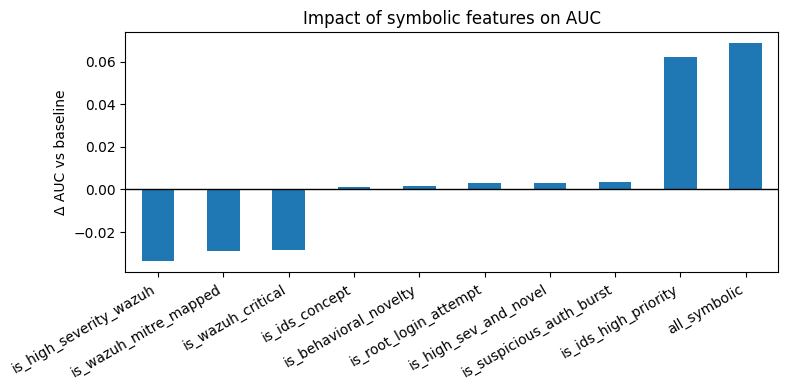

In [4]:
results_dict = {"base": res["diag_base"]}
for feat, diag in res["diag_ablation"].items():
    results_dict[feat] = diag
results_dict["all_symbolic"] = res["diag_sym_all"]

# impact of symbolic features on AUC (delta AUC over all alerts)
plot_symbolic_performance_delta(results_dict, metric="auc", out_dir=out_dir)

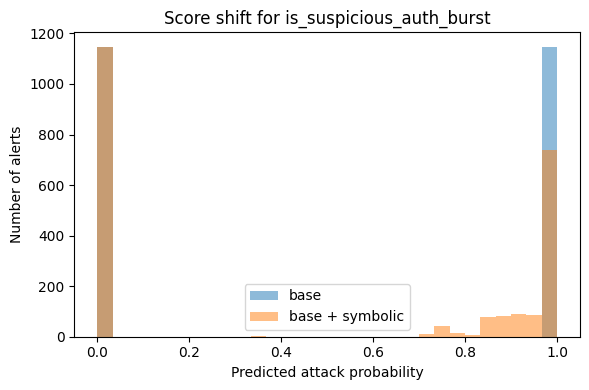

No test samples for feature is_root_login_attempt


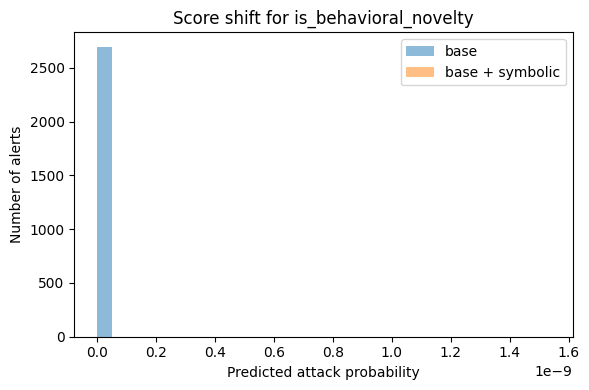

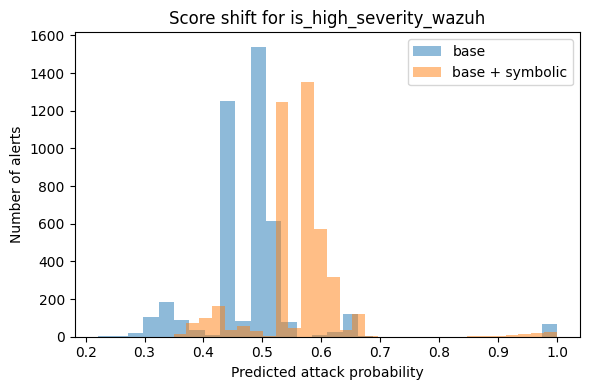

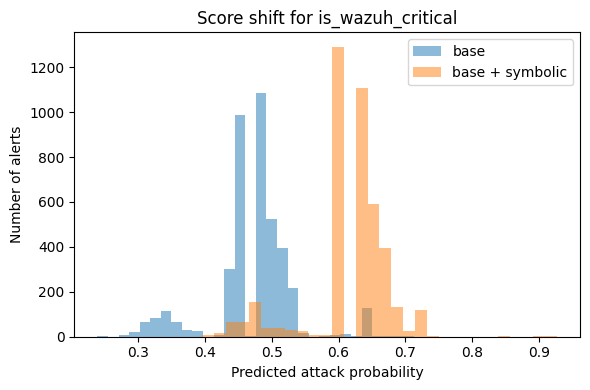

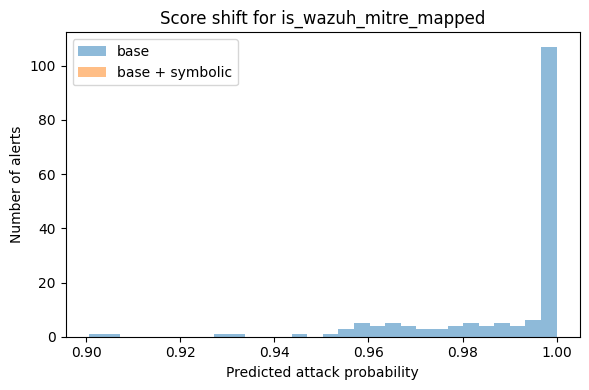

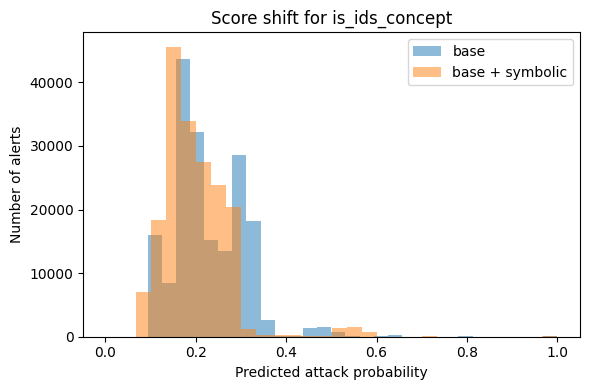

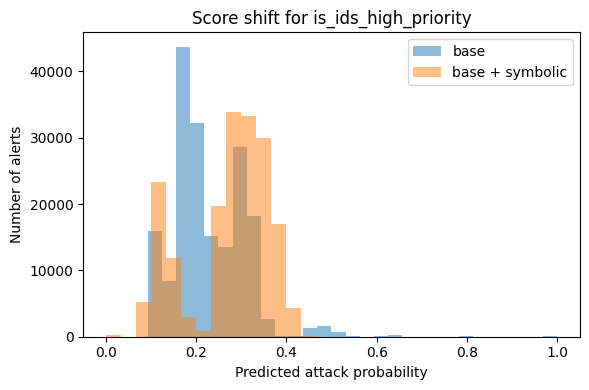

No test samples for feature is_high_sev_and_novel


In [5]:
out_dir = os.path.join(out_dir, "ablation_score_shifts")
os.makedirs(out_dir, exist_ok=True)

for f in res["sym_feats"]:
    res_feat = res["ablation"].get(f)

    if res_feat is None:
        print(f"Skipping {f} (no ablation result)")
        continue
    
    # plot score shift only for alerts where symbolic feature = 1
    # does adding a symbolic feature to the base model push predicted risk higher?
    plot_symbolic_score_shift(
        X_full=res["X_full"],
        res_base=res["base"],
        res_sym=res_feat,         
        feature=f,
        out_dir=out_dir,
        prefix=f
    )

In [10]:
out_dir = os.path.join(out_dir, "ablation_coefficients")

os.makedirs(out_dir, exist_ok=True)

for feat in res["sym_feats"]:
    res_feat = res["ablation"].get(feat)

    if res_feat is None:
        print(f"Skipping {feat} (no ablation model)")
        continue

    plot_symbolic_coefficients(
        model=res_feat["model"],
        feature_names=res_feat["feature_names"],
        symbolic_features=[feat],   # plot for one feature
        out_dir=out_dir,
        prefix=feat
    )

coef_sym:  is_suspicious_auth_burst   -8.51385
dtype: float64
coef_sym:  is_root_login_attempt    0.0
dtype: float64
coef_sym:  is_behavioral_novelty   -24.414077
dtype: float64
coef_sym:  is_high_severity_wazuh   -0.157816
dtype: float64
coef_sym:  is_wazuh_critical    0.13124
dtype: float64
coef_sym:  is_wazuh_mitre_mapped    5.072561
dtype: float64
coef_sym:  is_ids_concept    1.344127
dtype: float64
coef_sym:  is_ids_high_priority   -48.109207
dtype: float64
coef_sym:  is_high_sev_and_novel    0.0
dtype: float64
